# 06 MiniMind LoRA

阶段 5 的 Full SFT 使用 SFT 数据继续更新 MiniMind 的全部参数。LoRA（Low-Rank Adaptation）在选定的 Linear 旁增加 A、B 两块小矩阵，两者合称 adapter。阶段 6 保留相同的 SFT 数据流和 next-token loss，改为冻结原模型参数，只训练 adapters。

本 Notebook 先用 toy model 直接观察 LoRA 的 Tensor 与参数，再读取真实 MiniMind capacity check 和正式训练产物。toy model 用于解释 shape、初始化、参数冻结、adapter reload，以及把 LoRA update 加到对应 Base weight 的 merge。

阅读顺序为：Full SFT 与 LoRA 的关系 → 一个 Linear 的 LoRA forward → target modules 注入与冻结 → 第一次 optimizer step → adapter reload 与 merge → MiniMind 64M 参数量 → 显存边界 → 正式对照配置 → 正式训练结果 → 固定生成 → 七任务评估 → QLoRA。

真实 MiniMind 训练、三方固定生成和七任务评估均已完成。本 Notebook 将原理、配置与实验结果分开呈现。

## 1. LoRA 改变的是哪些参数参与更新

Base model 指加载阶段 4 Pretrain checkpoint 后得到的原 MiniMind；Base weights 指这个模型中已经存在的参数。接收 LoRA 的原 Linear 称为 target module。每个 target module 安装一个 LoRA adapter，一个 adapter 由一对 A、B weights 组成。一个模型可以有多个 target modules，因此也可以有多个 adapters。

Full SFT 与 LoRA 都先执行完整 forward，再根据 assistant response 与 EOS 计算 loss，随后执行 backward。区别发生在 optimizer 可以更新哪些参数：

```text
同一个 SFT batch
→ MiniMind forward
→ assistant response 与 EOS 上的 next-token loss
→ backward
   ├─ Full SFT：保存 Base parameter gradients，并更新 Base weights
   └─ LoRA：不保存 Base parameter gradients，只更新 adapter weights
```

| 比较维度 | Full SFT | LoRA |
| --- | --- | --- |
| 初始模型 | 阶段 4 Pretrain checkpoint | 阶段 4 Pretrain checkpoint |
| 训练数据 | SFT conversations | 相同的 SFT conversations |
| 输入与监督目标 | 相同的 chat template 和 response mask | 相同的 chat template 和 response mask |
| forward | 使用原模型全部 Linear | target Linear 的输出加上 LoRA update |
| Base parameter gradients | 计算并保存 | 不计算，`.grad` 为 `None` |
| Activation gradients | 沿计算图向较早层传递 | 同样传递，用于计算各层 A、B 的 gradients |
| Base weights 更新 | 由 optimizer 更新 | 冻结，不参与 optimizer update |
| 新增的 trainable parameters | 无 | target Linear 各增加 A、B |
| optimizer 管理的参数 | 全部 Base parameters | 只有 A、B |
| loss | assistant response 与 EOS 上的 next-token loss | 相同的 next-token loss |
| task-specific weights | 完整模型权重 | 只需保存 adapter weights |

本阶段从阶段 4 checkpoint 开始训练 LoRA，用于和阶段 5 Full SFT 比较。

In [1]:
# 导入小例子需要的实现，不加载模型或启动训练。
from copy import deepcopy
import json
from pathlib import Path
import statistics

import matplotlib.pyplot as plt
import torch
from torch import nn
from IPython.display import Markdown, display

from llm_learning.minimind.lora import (
    LoRAAdapter,
    adapter_state_dict,
    apply_lora,
    count_parameters,
    freeze_non_lora_parameters,
    load_adapter_state_dict,
    merge_lora_,
)
from llm_learning.minimind.lora_config import load_lora_config

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device_name = torch.cuda.get_device_name(device) if device.type == "cuda" else "CPU"

print("运行环境")
print(f"  PyTorch:     {torch.__version__}")
print(f"  device:      {device}")
print(f"  device name: {device_name}")

运行环境
  PyTorch:     2.9.1
  device:      cuda:0
  device name: NVIDIA GeForce RTX 4060 Laptop GPU


## 2. 一个 Linear 怎样安装 LoRA adapter

先定义符号。$W$ 是原 Linear weight，$A$ 和 $B$ 是 LoRA 新增的两个 Linear weights，$r$ 是它们之间的中间维度，也就是 rank。为避免和 LoRA 矩阵 $B$ 混淆，本 Notebook 用 $N$ 表示 batch size。

Full SFT 直接更新完整的 $W$。LoRA 冻结 $W$，把任务带来的权重增量写成 $\Delta W=BA$。四块矩阵的关系如下：

| 矩阵 | shape | 作用 |
| --- | --- | --- |
| $W$ | $[D_{\text{out}},D_{\text{in}}]$ | 原 Linear weight，冻结 |
| $A$ | $[r,D_{\text{in}}]$ | 把输入最后一维压到 rank $r$ |
| $B$ | $[D_{\text{out}},r]$ | 从 rank $r$ 恢复到输出维度 |
| $BA$ | $[D_{\text{out}},D_{\text{in}}]$ | 与 $W$ 同 shape 的权重增量 |

$BA$ 的 rank 不超过 $r$，所以称为 low-rank adaptation。真正形成低秩瓶颈需要 $r$ 远小于输入、输出维度。LoRA 依赖的假设是：当前任务需要的权重增量可以用较低 rank 近似；正式实验再检查这种限制下的实际效果。

先用函数记号描述两条分支。$W(x)$ 表示原 Linear 作用于输入 $x$，$B(A(x))$ 表示输入依次经过 A、B。两条分支的输出 shape 相同，因此可以相加：

$$
y = W(x) + B(A(x))
$$

这里的 $W(x)$ 是函数记号，不表示代码直接执行 `W.weight @ x`。PyTorch 把每个输入 vector 放在最后一维，把 Linear weight 保存为 `[out_features, in_features]`。因此 `nn.Linear` 的实际矩阵乘法是 `x @ weight.T`。

下面的小例子把 3 个 4 维 vectors 按行放入 `x`，所以 `x` 是一个 3 行 4 列的普通二维 Tensor：

| 运算 | 左矩阵 | 右矩阵 | 结果 |
| --- | ---: | ---: | ---: |
| `x @ W.weight.T` | `[3,4]` | `[4,6]` | `[3,6]` |
| `x @ A.weight.T` | `[3,4]` | `[4,2]` | `[3,2]` |
| `A(x) @ B.weight.T` | `[3,2]` | `[2,6]` | `[3,6]` |

第一行得到 Base output，后两行组成 LoRA increment。这里没有改变二维矩阵的行列定义，也没有把输入或输出 Tensor 转置；`.T` 只作用于按 `[out_features, in_features]` 保存的 weight。于是代码中的两条分支可以准确展开为：

```text
W(x)       = x @ W.weight.T
B(A(x))    = (x @ A.weight.T) @ B.weight.T
最终输出 y = W(x) + B(A(x))
```

Transformer hidden states 的 shape 是 $[N,T,D_{\text{in}}]$。`nn.Linear` 保留前面的 batch 与 sequence 维度，只把最后一维从 $D_{\text{in}}$ 映射为 $D_{\text{out}}$：

```text
Base Linear:  [N, T, D_in] ── W ─────→ [N, T, D_out]
LoRA adapter: [N, T, D_in] ── A ─────→ [N, T, rank]
                              └─ B ─────→ [N, T, D_out]
两条分支逐元素相加 ─────────────────────→ [N, T, D_out]
```

下面使用 3 个 hidden vectors，每个 vector 有 4 个元素。原 Linear 把每行从 4 维映射到 6 维；rank 2 的 LoRA 先压到 2 维，再恢复到 6 维。正式配置使用 rank 16。

```text
                         ┌→ W（冻结）──────────→ base output [3, 6] ─┐
x [3, 4] ────────────────┤                                         ├→ y [3, 6]
                         └→ A（训练）→ [3, 2] → B（训练）→ [3, 6] ─┘
```

三块 weight 的 shape 分别为 `W.weight=[6,4]`、`A.weight=[2,4]`、`B.weight=[6,2]`。代码单元验证上述每一步的输出 shape。

In [2]:
# 用 3 个 hidden vectors 检查 Base Linear 与 LoRA adapter 的输出 shape。
torch.manual_seed(42)
inputs = torch.randn(3, 4, device=device)
base_linear = nn.Linear(4, 6, bias=False).to(device)
adapter = LoRAAdapter(in_features=4, out_features=6, rank=2).to(device)
base_output = base_linear(inputs)
low_rank_hidden = adapter.A(inputs)
increment = adapter.B(low_rank_hidden)
combined_output = base_output + increment

print("运行环境")
print(f"  device: {base_linear.weight.device}")
print(f"  dtype:  {base_linear.weight.dtype}")
print("输入")
print(f"  x:        {tuple(inputs.shape)}")
print("Base Linear")
print(f"  W.weight: {tuple(base_linear.weight.shape)}")
print(f"  W(x):     {tuple(base_output.shape)}")
print("LoRA adapter")
print(f"  A.weight: {tuple(adapter.A.weight.shape)}")
print(f"  A(x):     {tuple(low_rank_hidden.shape)}")
print(f"  B.weight: {tuple(adapter.B.weight.shape)}")
print(f"  B(A(x)):  {tuple(increment.shape)}")
print("相加结果")
print(f"  y:        {tuple(combined_output.shape)}")
print(f"  初始 LoRA increment 全为零: {torch.equal(increment, torch.zeros_like(increment))}")
print(f"  注入前后输出完全相同: {torch.equal(combined_output, base_output)}")

运行环境
  device: cuda:0
  dtype:  torch.float32
输入
  x:        (3, 4)
Base Linear
  W.weight: (6, 4)
  W(x):     (3, 6)
LoRA adapter
  A.weight: (2, 4)
  A(x):     (3, 2)
  B.weight: (6, 2)
  B(A(x)):  (3, 6)
相加结果
  y:        (3, 6)
  初始 LoRA increment 全为零: True
  注入前后输出完全相同: True


输出先验证了两件事：Base Linear 与 LoRA adapter 都得到 `[3,6]`，所以能够逐元素相加；LoRA increment 初始全为零，所以注入 adapter 后的输出与原 Linear 完全相同。

初始增量为零来自初始化方式：$A$ 使用小随机数，$B$ 的所有参数为零。此时 $A(x)$ 通常不是零，但再经过 $B$ 后得到零。这样可以从原 Base model 的行为开始训练。

### 为什么 B 全零仍然能够开始学习

普通 Dense layer 如果把所有神经元的 weight 都初始化为零，不同神经元会得到相同输出和相同 gradient，无法打破 symmetry。LoRA 的情况不同，因为这里只有 $B$ 为零，$A$ 已经随机初始化。

第一次 backward 时，两块 weight 的 gradient 来源不同：

```text
B 的 gradient ← 上游 gradient 与随机的 A(x)
A 的 gradient ← 上游 gradient 经过当前的 B
```

随机的 $A$ 会产生不同的中间 features，所以 $B$ 的参数通常得到不同且非零的 gradients，不会保持对称。此时 $B=0$，传回 $A$ 的 gradient 为零，因此第一次 optimizer step 只改变 $B$。完成这一步后 $B$ 不再为零，从下一次 backward 开始，$A$ 通常也能获得非零 gradient。

如果把 $A$ 和 $B$ 同时初始化为零，$B$ 的 gradient 会因为 $A(x)=0$ 而为零，$A$ 的 gradient 也会因为 $B=0$ 而为零，两者都无法开始学习。因此 LoRA 使用“一块随机、一块全零”，同时满足两个目标：初始 increment 为零，并且训练可以从第一次 backward 开始。第 4 节会用实际 gradient 验证这个过程。

本项目的 A、B 都设置 `bias=False`，因此参数量只计算两块 weight。原矩阵需要 $6 \times 4 = 24$ 个参数；这个 rank-2 adapter 需要 $2 \times 4 + 6 \times 2 = 20$ 个参数。一般情况下，若 rank 记为 $r$，adapter 参数量为：

$$
rD_{\text{in}}+D_{\text{out}}r=r(D_{\text{in}}+D_{\text{out}})
$$

rank 表示 $A(x)$ 的最后一维，不表示层数、attention head 数或 target module 数。rank 越大，单个 adapter 的参数量按比例增加。小例子的维度很低，因此节省不明显；当输入和输出维度都是 768、rank 只有 16 时，两块窄矩阵才远小于一块完整方阵。

一些 LoRA 实现会设置 `alpha` 作为 adapter scaling hyperparameter，再把增量乘以 `alpha / rank`。当前 MiniMind 没有 `alpha` 配置，直接使用 $B(A(x))$。本阶段保持 MiniMind 的定义。

## 3. 注入 target modules，再冻结 Base parameters

target module 是安装 LoRA adapter 的原 Linear。配置写的是 Linear 的末级名称，例如 `q_proj`；注入结果使用完整名称，例如 `layers.0.q_proj`，用于确认每一层实际选中了什么。一个 target module 对应一个 adapter，不是整个模型共用一个 adapter。

注入与冻结是两个独立步骤：

1. `apply_lora` 为选中的 Linear 增加 `.lora.A` 与 `.lora.B`，并把 forward 改为 `原 Linear 输出 + LoRA increment`；
2. `freeze_non_lora_parameters` 把原模型参数设为不可训练，只保留 A、B 的 `requires_grad=True`。

下面的 toy model 有 2 层，每层都声明 Q、K、V、O 四个 Linear。层数通过 `num_layers` 传入。toy forward 只用 `q_proj → o_proj` 模拟多层调用，不执行真实 attention；K/V 只用于检查未被配置选中时不会注入 LoRA。

In [3]:
# 检查 target modules、初始输出和可训练参数范围。
class TinyAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.q_proj = nn.Linear(4, 4, bias=False)
        self.k_proj = nn.Linear(4, 2, bias=False)
        self.v_proj = nn.Linear(4, 2, bias=False)
        self.o_proj = nn.Linear(4, 4, bias=False)

    def forward(self, hidden_states):
        return self.o_proj(self.q_proj(hidden_states))


class TinyModel(nn.Module):
    def __init__(self, num_layers):
        super().__init__()
        self.layers = nn.ModuleList(
            [TinyAttention() for _ in range(num_layers)]
        )

    def forward(self, hidden_states):
        for layer in self.layers:
            hidden_states = layer(hidden_states)
        return hidden_states


torch.manual_seed(7)
toy_num_layers = 2
tiny_model = TinyModel(num_layers=toy_num_layers)
base_state = deepcopy(tiny_model.state_dict())
inspection_input = torch.randn(3, 4)
output_before_lora = tiny_model(inspection_input).detach().clone()
targets = apply_lora(
    tiny_model,
    rank=2,
    target_module_names=("q_proj", "o_proj"),
)
freeze_non_lora_parameters(tiny_model)
output_after_lora = tiny_model(inspection_input).detach()
parameter_counts = count_parameters(tiny_model)

print("target module 检查")
print("  配置请求: q_proj, o_proj")
print(f"  {toy_num_layers} 层 × 每层 2 个 targets = {len(targets)} 个 LoRA adapters")
print("  实际完整名称:")
for name in targets:
    print(f"    {name}")
print(f"  K/V 未被注入: {all('.k_proj' not in name and '.v_proj' not in name for name in targets)}")
print("初始化检查")
print(f"  注入前后输出完全相同: {torch.equal(output_before_lora, output_after_lora)}")
print("参数量")
print(f"  冻结的 Base parameters: {parameter_counts['total'] - parameter_counts['lora']}")
print(f"  LoRA parameters:         {parameter_counts['lora']}")
print(f"  注入后的总参数:          {parameter_counts['total']}")
print(f"  trainable parameters:    {parameter_counts['trainable']}")
print("可训练参数名称与 shape")
for name, parameter in tiny_model.named_parameters():
    if parameter.requires_grad:
        print(f"  {name}: {tuple(parameter.shape)}")

target module 检查
  配置请求: q_proj, o_proj
  2 层 × 每层 2 个 targets = 4 个 LoRA adapters
  实际完整名称:
    layers.0.q_proj
    layers.0.o_proj
    layers.1.q_proj
    layers.1.o_proj
  K/V 未被注入: True
初始化检查
  注入前后输出完全相同: True
参数量
  冻结的 Base parameters: 96
  LoRA parameters:         64
  注入后的总参数:          160
  trainable parameters:    64
可训练参数名称与 shape
  layers.0.q_proj.lora.A.weight: (2, 4)
  layers.0.q_proj.lora.B.weight: (4, 2)
  layers.0.o_proj.lora.A.weight: (2, 4)
  layers.0.o_proj.lora.B.weight: (4, 2)
  layers.1.q_proj.lora.A.weight: (2, 4)
  layers.1.q_proj.lora.B.weight: (4, 2)
  layers.1.o_proj.lora.A.weight: (2, 4)
  layers.1.o_proj.lora.B.weight: (4, 2)


输出中的 4 个完整模块名与配置相符：

- 2 层 × 每层 2 个 target modules = 4 个 LoRA adapters；
- 每个 target Linear 都是 4 维到 4 维，因此每个 rank-2 adapter 有 $2 \times 4 + 4 \times 2 = 16$ 个参数；
- 4 个 adapters 共有 $4 \times 16 = 64$ 个参数，它们就是全部 trainable parameters；
- K/V 没有 `.lora` 子模块，Base weights 也全部冻结。

第 2 节的单个 adapter 接在一个 4 维到 6 维的 Linear 上，所以有 20 个参数；本节的每个 adapter 接在 4 维到 4 维的 Q/O Linear 上，所以各有 16 个参数。adapter 参数量取决于对应 target module 的输入、输出维度。

每层 toy Base parameters 为 `q_proj 16 + k_proj 8 + v_proj 8 + o_proj 16 = 48`，两层共有 96 个。三个状态需要分开看：

| 状态 | total parameters | trainable parameters |
| --- | ---: | ---: |
| 注入 LoRA 前 | 96 | 96，全部是 Base parameters |
| 注入 4 个 adapters 后，冻结前 | 160 | 160，Base 与 adapters 都可训练 |
| 冻结 Base parameters 后 | 160 | 64，只有 adapters 可训练 |

注入 adapters 会新增参数，因此 total parameters 从 96 增加到 160。冻结只改变参数的 `requires_grad`，不会删除 Base parameters，因此 total parameters 仍是 160，而 trainable parameters 降为 64。

## 4. 第一次 backward 与 optimizer step 更新了什么

Base parameters 设置 `requires_grad=False` 后，backward 不计算它们的 parameter gradients，`.grad` 保持 `None`，optimizer 也不会更新它们。为了计算各层 A、B 的 parameter gradients，autograd 仍需计算 hidden states 等中间 Tensor 的 activation gradients，并沿冻结的 Base layers 向较早层传递。

optimizer 只接收 `requires_grad=True` 的 A、B。第一次更新还有一个由零初始化带来的特殊现象：

| 参数 | 第一次 backward 的 gradient | 第一次 optimizer step 是否改变 | 原因 |
| --- | --- | --- | --- |
| Base weights | 不保存 | 否 | 已冻结，也没有交给 optimizer |
| A | 为零 | 否 | 传到 A 的 gradient 需要乘以当前全零的 B |
| B | 通常非零 | 是 | B 的 gradient 可以由 A(x) 与上游 gradient 直接得到 |

B 完成第一次更新后不再全零，后续 steps 中 A 通常也会获得非零 gradient。下面使用人为构造的 MSE loss，只检查 gradient 与更新范围；正式 SFT 使用 assistant response 与 EOS 上的 next-token cross entropy。示例把 AdamW 的 `weight_decay` 设为 0，避免额外数值变化干扰观察。

In [4]:
# 执行一次 optimizer step，并验证 Base parameters 没有改变。
base_before_step = {
    name: parameter.detach().clone()
    for name, parameter in tiny_model.named_parameters()
    if ".lora." not in name
}
adapter_before_step = adapter_state_dict(tiny_model)
optimizer_parameters = [
    parameter for parameter in tiny_model.parameters() if parameter.requires_grad
]
optimizer = torch.optim.AdamW(
    optimizer_parameters,
    lr=0.1,
    weight_decay=0.0,
)
target = torch.ones_like(output_after_lora)
loss = (tiny_model(inspection_input) - target).square().mean()
loss.backward()

a_gradient_norm = sum(
    parameter.grad.norm().item()
    for name, parameter in tiny_model.named_parameters()
    if name.endswith("lora.A.weight")
)
b_gradient_norm = sum(
    parameter.grad.norm().item()
    for name, parameter in tiny_model.named_parameters()
    if name.endswith("lora.B.weight")
)
base_gradients_absent = all(
    parameter.grad is None
    for name, parameter in tiny_model.named_parameters()
    if ".lora." not in name
)
optimizer.step()
adapter_after_step = adapter_state_dict(tiny_model)
base_unchanged = all(
    torch.equal(parameter, base_before_step[name])
    for name, parameter in tiny_model.named_parameters()
    if name in base_before_step
)
output_changed = not torch.equal(
    tiny_model(inspection_input).detach(),
    output_after_lora,
)
a_parameters_unchanged = all(
    torch.equal(adapter_after_step[name], adapter_before_step[name])
    for name in adapter_before_step
    if name.endswith("lora.A.weight")
)
b_parameters_changed = any(
    not torch.equal(adapter_after_step[name], adapter_before_step[name])
    for name in adapter_before_step
    if name.endswith("lora.B.weight")
)

print("optimizer 范围")
print(f"  接收的参数量: {sum(parameter.numel() for parameter in optimizer_parameters)}")
print("backward 结果")
print(f"  loss: {loss.item():.6f}")
print(f"  A gradient norms 之和: {a_gradient_norm:.6f}")
print(f"  B gradient norms 之和: {b_gradient_norm:.6f}")
print(f"  Base parameter gradients 都是 None: {base_gradients_absent}")
print("第一次 optimizer step 后")
print(f"  Base parameters 保持不变: {base_unchanged}")
print(f"  A parameters 保持不变:    {a_parameters_unchanged}")
print(f"  B parameters 已经改变:    {b_parameters_changed}")
print(f"  模型输出已由 adapter 改变: {output_changed}")

optimizer 范围
  接收的参数量: 64
backward 结果
  loss: 1.032452
  A gradient norms 之和: 0.000000
  B gradient norms 之和: 0.020348
  Base parameter gradients 都是 None: True
第一次 optimizer step 后
  Base parameters 保持不变: True
  A parameters 保持不变:    True
  B parameters 已经改变:    True
  模型输出已由 adapter 改变: True


输出与初始化推导一致：optimizer 只接收 64 个 LoRA parameters；第一次 backward 后 A 的 gradient norm 为 0，B 的 gradient norm 非零；第一次 optimizer step 只改变 B。Base parameters 没有 `.grad`，数值也保持不变。

B 改变后，LoRA increment 不再全为零，因此同一个输入的模型输出发生变化。这说明 adapter 已开始学习，同时没有修改 Base weights。这个单步示例只证明当前实现的更新范围正确，不证明 LoRA 的正式训练效果。

## 5. Adapter reload 与 merge 分别做什么

训练中的 LoRA 模型由 Base weights 与 adapter weights 共同组成。adapter weights 只保存 A、B，文件较小，但不能单独完成 forward；reload 时必须先建立相同的 Base model，再注入相同 rank 和 target modules，最后加载 A、B。

### 三种训练产物

本阶段会出现三种用途不同的训练产物：

| 产物 | 主要内容 | 用途 | 能否恢复 optimizer step |
| --- | --- | --- | --- |
| adapter weights | A、B 与 Base 身份、rank、target modules | 配合相同 Base model 推理或切换 adapter | 否 |
| merged weights | 完整模型权重；target weight 已替换为 $W_{\text{merged}}=W+BA$ | 按普通模型加载、转换和部署 | 否 |
| resume checkpoint | 模型、optimizer、step、配置、数据状态与 RNG（随机数状态） | 中断后继续训练 | 是 |

### reload 与 merge

```text
reload:  相同 Base weights + 保存的 A、B → 恢复 LoRA 模型
merge:   W_merged = W + B.weight @ A.weight
         删除独立 adapter 结构 → 得到普通 Linear
```

普通 LoRA forward 依次计算 `A(x)` 与 `B(A(x))`，不会先生成完整的 $BA$ 矩阵。merge 才显式计算一次 `B.weight @ A.weight`，再与对应的 Base weight $W$ 逐元素相加，得到 $W_{\text{merged}}$。

`merged weights` 中的 `weights` 指完整模型的全部 weights。对于安装过 adapter 的 Q/O Linear，保存的是 $W_{\text{merged}}$；embedding、K/V、MLP、Norm 等其他 weights 原样保留。$BA$ 不再作为独立矩阵保存在 merged weights 中，A、B 结构也会被移除。

下面把刚更新的 8 个 adapter tensors 加载到同一份 toy Base weights，比较 reload 前后的输出；随后执行 merge，再比较 merge 前后的输出。这里只检查内存中的 adapter state dict 与 merge，不检查文件保存或 resume。

In [5]:
# 验证 adapter reload 与 merge 都保持当前输出。
saved_adapter = adapter_state_dict(tiny_model)
expected_output = tiny_model(inspection_input).detach().clone()

reloaded_model = TinyModel(num_layers=toy_num_layers)
reloaded_model.load_state_dict(base_state)
apply_lora(
    reloaded_model,
    rank=2,
    target_module_names=("q_proj", "o_proj"),
)
load_adapter_state_dict(reloaded_model, saved_adapter)
reloaded_output = reloaded_model(inspection_input).detach().clone()
merged_names = merge_lora_(reloaded_model)
merged_output = reloaded_model(inspection_input).detach()
reload_max_difference = (reloaded_output - expected_output).abs().max().item()
merge_max_difference = (merged_output - expected_output).abs().max().item()

remaining_lora_parameters = [
    name for name, _ in reloaded_model.named_parameters() if ".lora." in name
]

print("保存的 adapter")
print(f"  tensors:    {len(saved_adapter)}")
print(f"  parameters: {sum(tensor.numel() for tensor in saved_adapter.values())}")
print("reload 检查")
print(f"  与保存前输出的最大绝对差: {reload_max_difference:.3e}")
print("merge 检查")
print(f"  合并的 modules: {merged_names}")
print(f"  剩余 LoRA parameter names: {remaining_lora_parameters}")
print(f"  与 merge 前输出的最大绝对差: {merge_max_difference:.3e}")

保存的 adapter
  tensors:    8
  parameters: 64
reload 检查
  与保存前输出的最大绝对差: 0.000e+00
merge 检查
  合并的 modules: ('layers.0.q_proj', 'layers.0.o_proj', 'layers.1.q_proj', 'layers.1.o_proj')
  剩余 LoRA parameter names: []
  与 merge 前输出的最大绝对差: 2.980e-08


state dict 是按参数名保存 Tensor 的字典。4 个 LoRA adapters 各有 A、B 两块 weight，因此 adapter state dict 包含 8 个 tensors，共 64 个参数。这里的 adapter state dict 是全部 adapters 的权重集合。reload 后最大绝对差为 0，说明相同 Base weights 加载相同 adapter weights 后恢复了同一输出。

merge 后不再存在 `.lora` parameters。merge 前后的最大绝对差约为 $10^{-8}$，来自浮点运算顺序变化；当前 toy 输入上的输出在数值容差内一致。merge 产生的是一份完整模型权重；未合并的 adapter checkpoint 仍需配合原 Base checkpoint。

## 6. 为什么 MiniMind 64M 选择 Q/O

MiniMind 官方 LoRA 实现的选择条件是 `in_features == out_features`，也就是只给方形 Linear 注入 adapter。这个条件在当前 64M Dense 结构中恰好选中每层 attention 的 `q_proj` 与 `o_proj`。它是一条实现规则，不表示 LoRA 理论上只能用于 Q/O。

MiniMind 64M 的 hidden size 为 768，query heads 为 8，KV heads 为 4，每个 head 为 96 维。Q 保留 $8 \times 96=768$ 维；GQA 的 K/V 只有 $4 \times 96=384$ 维。O 再把拼接后的 query-head 维度映射回 768。各 Linear 因此具有下面的输入、输出维度：

| Linear | 输入维度 | 输出维度 | 官方规则是否注入 |
| --- | ---: | ---: | --- |
| `q_proj` | 768 | 768 | 是 |
| `k_proj`、`v_proj` | 768 | 384 | 否 |
| `o_proj` | 768 | 768 | 是 |
| `gate_proj`、`up_proj` | 768 | intermediate size | 否 |
| `down_proj` | intermediate size | 768 | 否 |
| `lm_head` | 768 | 6,400 | 否 |

当前模型有 8 层，因此 `8 层 × 每层 Q/O 两个 targets = 16 个 target Linear`。本项目把官方规则得到的 `q_proj`、`o_proj` 显式写入配置，并在训练前核对 16 个完整模块名。这样能在模型结构变化时直接发现 target modules 已改变。其他 LoRA 项目可以选择 K/V、MLP 或更多 Linear。

一个 Q/O weight 的 shape 为 `[768,768]`。rank 16 adapter 的参数量为：

$$
16 \times 768 + 768 \times 16 = 24{,}576
$$

16 个 target Linear 的参数量如下：

| 项目 | 参数量 | 在本阶段的状态 |
| --- | ---: | --- |
| 一个完整 `[768,768]` target weight | 589,824 | LoRA 中冻结 |
| 一个 rank-16 adapter | 24,576 | 参与训练 |
| 16 个 adapters | 393,216 | 全部参与训练 |
| 原 MiniMind 64M Base parameters | 63,912,192 | Full SFT 全部参与训练；LoRA 全部冻结 |
| 注入后的模型总参数 | 64,305,408 | Base 与 adapters 之和 |
| LoRA / Full SFT trainable parameters | 约 0.62% | 393,216 / 63,912,192 |

这里有两个不同的比例。对一个 `[768,768]` target Linear，rank-16 adapter 是原 weight 参数量的约 4.17%；对完整 64M 模型，16 个 adapters 的总参数量是 Full SFT trainable parameters 的约 0.62%。前者的分母是一块 target weight，后者的分母是整个 Base model，不能混用。

真实 64M capacity check 枚举了 8 层共 16 个 `q_proj` 与 `o_proj`，从模型对象实测得到 393,216 个 LoRA parameters，与上面的结构推导一致。

## 7. LoRA 节省了什么，没有省掉什么

训练显存可以分成 parameter 相关状态与 forward activations。LoRA 的主要节省来自前一类：冻结 Base parameters 后，不再为它们保存 parameter gradients 和 AdamW 的一阶、二阶状态。

| 显存内容 | Full SFT | LoRA |
| --- | --- | --- |
| Base weights | 保存 | 保存 |
| Base parameter gradients | 保存 | 不保存 |
| Base AdamW states | 保存 | 不保存 |
| Adapter weights、gradients、AdamW states | 无 | 保存 |
| Forward activations | 保存 | 仍需保存相关部分 |

模型仍要执行完整 Transformer forward 和 LM head。backward 不生成 Base parameter gradients，但仍需使用保存的 forward activations 计算 A、B 的 gradients，并把 activation gradients 经过冻结层传到较早层；每个 target Linear 还多执行 A、B 两个小矩阵乘法。

因此 0.62% 的 trainable parameter ratio 只描述参与更新的参数量，不表示显存或训练时间也变为 Full SFT 的 0.62%。正式比较必须固定 batch size、sequence length、设备与评估口径，再实测 peak GPU memory、tokens/s 和 wall time。

## 8. 正式对照配置

前面的小例子解释了 LoRA 的机制。下面回到正式实验，读取配置并展示计划参数。

正式对照固定以下输入条件：

| 保持一致 | Full SFT 与 LoRA 的设置 |
| --- | --- |
| 初始模型 | 同一个阶段 4 Pretrain checkpoint |
| 数据 | 同一个 SFT 文件与 train/validation split |
| batch | batch size 16，sequence length 768 |
| 训练长度 | 56,480 optimizer steps |
| 评估 | 相同 validation、固定 prompts 和七任务 |

两项设置有意不同：Full SFT 更新全部 Base parameters，learning rate 为 `1e-5`；LoRA 只更新 rank-16 Q/O adapters，learning rate 为 `1e-4`。因此这是两套固定实用配置的对照，不是只改变参数化方式的单变量消融实验。

最终比较 trainable parameters、peak GPU memory、tokens/s、wall time、validation loss、权重文件大小、固定生成和七任务结果。阶段 4 与阶段 5 的已有产物直接读取。正式 LoRA 训练使用阶段 README 中的 `lora_train` 命令执行一轮。

In [6]:
# 读取正式对照配置；这里只展示计划，不启动训练。
config = load_lora_config(ROOT / "docs/stages/06_lora/configs/rank16.json")

print("实验身份")
print(f"  profile: {config.profile}")
print(f"  复用的阶段 5 训练配置: {config.base_sft_config}")
print(f"  初始 Pretrain weights: {config.base_weights_path}")
print("LoRA 专属参数")
print(f"  rank: {config.rank}")
print(f"  target modules: {config.target_modules}")
print(f"  learning rate: {config.learning_rate:.1e}")
print(f"  optimizer step 上限: {config.stop_after_step:,}")
print("输出位置")
print(f"  metrics: {config.output_dir}")
print(f"  checkpoints: {config.checkpoint_dir}")

实验身份
  profile: lora_rank16
  复用的阶段 5 训练配置: docs/stages/05_sft/configs/mini64.json
  初始 Pretrain weights: checkpoints/minimind/stage4/mini64/weights_step_9908.pth
LoRA 专属参数
  rank: 16
  target modules: ('q_proj', 'o_proj')
  learning rate: 1.0e-04
  optimizer step 上限: 56,480
输出位置
  metrics: outputs/minimind/stage6/rank16
  checkpoints: checkpoints/minimind/stage6/rank16


`base_sft_config` 表示复用阶段 5 的数据、split、batch size、sequence length 等训练设置；它不是初始模型权重。`base_weights_path` 才指定阶段 4 Pretrain checkpoint。

正式 train split 有 903,670 条序列，batch size 为 16，`accumulation_steps=1`。一次 optimizer step 处理一个 batch，因此一轮需要 $\lceil 903{,}670 / 16 \rceil = 56{,}480$ 个 optimizer steps。配置在这个位置停止，即只执行一轮，不盲目增加 epoch。

LoRA learning rate 为 `1e-4`，阶段 5 Full SFT 使用 `1e-5`。最终结果可以比较两套固定实用配置的资源与效果，不能把差异全部归因于参数更新范围。

当前分支已经接入真实 MiniMind、SFT Dataset 和共享训练循环。专项测试、capacity check 和一轮正式 rank-16 LoRA 均已完成，下一节读取实际训练结果。

## 9. 正式训练结果

LoRA 与 Full SFT 都从同一个阶段 4 Pretrain checkpoint 开始，使用相同 train/validation split，并各自处理 367,458,576 个 supervised response tokens。下面读取两次运行的 summary 和 metrics，比较效果、显存、吞吐与权重文件大小。

训练过程使用固定 256 条 validation subset；最终结果使用完整 2,048 条 validation。曲线只连接相同的 subset 口径，完整 validation 数值单独列入表格。

| Metric | LoRA | Full SFT |
| --- | ---: | ---: |
| Trainable parameters | 393,216 | 63,912,192 |
| Final validation subset loss | 1.8350 | 1.5381 |
| Full validation loss | 1.8640 | 1.5631 |
| Full validation perplexity | 6.450 | 4.773 |
| Peak allocated GPU memory | 4.48 GiB | 6.77 GiB |
| Median train tokens/s | 17,752 | 14,501 |
| Task-specific weights | 0.76 MiB adapter | 131.31 MiB full weights |

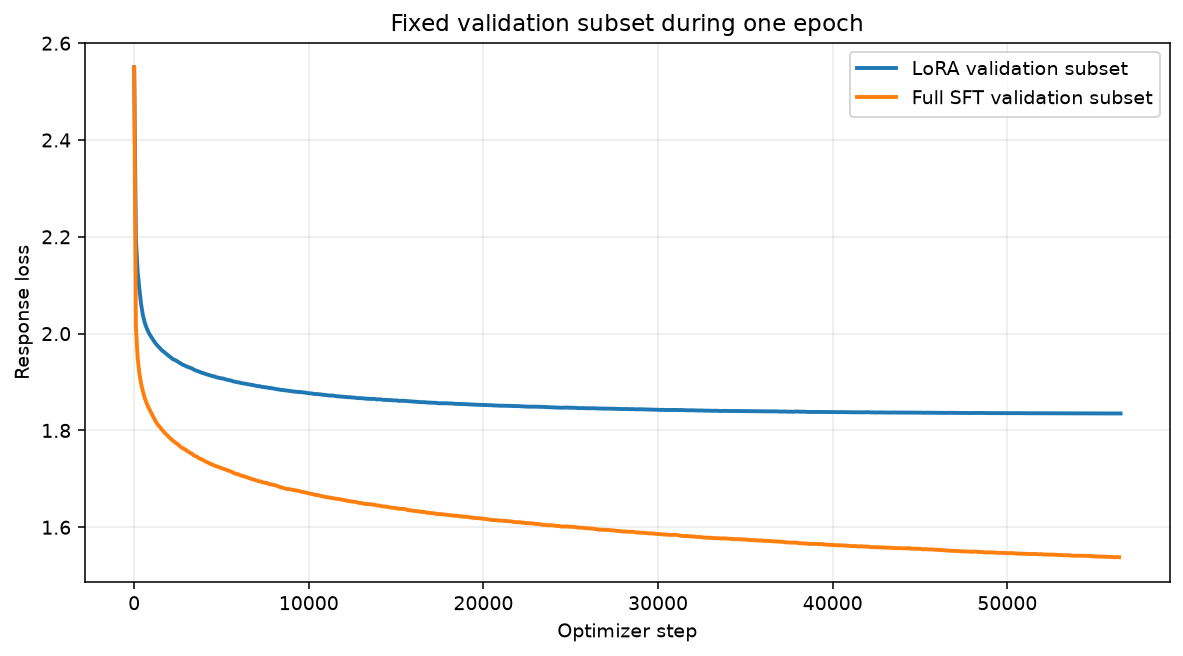

In [7]:
# 读取 LoRA 与 Full SFT 的固定口径结果。
def load_run(output_dir):
    summary = json.loads((output_dir / "summary.json").read_text(encoding="utf-8"))
    metrics = [
        json.loads(line)
        for line in (output_dir / "metrics.jsonl").read_text(encoding="utf-8").splitlines()
        if line
    ]
    train = [row for row in metrics if row["kind"] == "train"]
    validation_subset = [
        row
        for row in metrics
        if row["kind"] == "eval" and row["scope"] == "validation_subset"
    ]
    return summary, train, validation_subset

lora_summary, lora_train, lora_validation = load_run(
    ROOT / "outputs/minimind/stage6/rank16"
)
sft_summary, sft_train, sft_validation = load_run(
    ROOT / "outputs/minimind/stage5/mini64"
)

lora_adapter = ROOT / "checkpoints/minimind/stage6/rank16/adapter_step_56480.pth"
sft_weights = ROOT / "checkpoints/minimind/stage5/mini64/weights_step_56480.pth"
gib = 1024 ** 3
mib = 1024 ** 2
rows = [
    ("Trainable parameters", f"{lora_summary['trainable_parameter_count']:,}", f"{63_912_192:,}"),
    ("Final validation subset loss", f"{lora_validation[-1]['loss']:.4f}", f"{sft_validation[-1]['loss']:.4f}"),
    ("Full validation loss", f"{lora_summary['final_evaluation']['loss']:.4f}", f"{sft_summary['final_evaluation']['loss']:.4f}"),
    ("Full validation perplexity", f"{lora_summary['final_evaluation']['perplexity']:.3f}", f"{sft_summary['final_evaluation']['perplexity']:.3f}"),
    ("Peak allocated GPU memory", f"{lora_summary['peak_memory_bytes'] / gib:.2f} GiB", f"{sft_summary['peak_memory_bytes'] / gib:.2f} GiB"),
    ("Median train tokens/s", f"{statistics.median(row['tokens_per_second'] for row in lora_train):,.0f}", f"{statistics.median(row['tokens_per_second'] for row in sft_train):,.0f}"),
    ("Task-specific weights", f"{lora_adapter.stat().st_size / mib:.2f} MiB adapter", f"{sft_weights.stat().st_size / mib:.2f} MiB full weights"),
]
table = [
    "| Metric | LoRA | Full SFT |",
    "| --- | ---: | ---: |",
    *[f"| {name} | {lora_value} | {sft_value} |" for name, lora_value, sft_value in rows],
]
display(Markdown("\n".join(table)))

fig, ax = plt.subplots(figsize=(10, 5), dpi=140)
ax.plot(
    [row["optimizer_step"] for row in lora_validation],
    [row["loss"] for row in lora_validation],
    label="LoRA validation subset",
    linewidth=2,
)
ax.plot(
    [row["optimizer_step"] for row in sft_validation],
    [row["loss"] for row in sft_validation],
    label="Full SFT validation subset",
    linewidth=2,
)
ax.set(title="Fixed validation subset during one epoch", xlabel="Optimizer step", ylabel="Response loss")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

LoRA 的 validation subset loss 从 2.5504 降到 1.8350，完整 validation loss 为 1.8640。这说明只训练 Q/O adapters 也改善了同分布未见对话上的 response prediction。Full SFT 的完整 validation loss 为 1.5631，效果更好；LoRA 用较小的可训练参数空间换取了资源收益。

LoRA 的 peak allocated GPU memory 为 4.48 GiB，比 Full SFT 的 6.77 GiB 低约 33.8%；单 step tokens/s 中位数约为 17,752，比 Full SFT 高约 22.4%。adapter 文件只有 0.76 MiB，而 Full SFT 的任务权重约为 131.31 MiB。trainable parameters 只占 Full SFT 的约 0.62%，但显存和速度没有按这个比例变化，因为 Base weights、完整 Transformer forward，以及经过冻结层传递的 activation gradients 仍然存在。

曲线前段下降较快，20,000 steps 后改善逐渐变慢，在一轮末尾稳定在约 1.835。单个 batch 的 train loss 仍会上下波动，固定 validation 曲线保持平稳下降。

训练共用时约 6 小时 23 分钟。最终 adapter 和 merged weights 均已成功导出，后续生成与七任务评估使用 merged weights。

## 10. Pretrain、Full SFT 与 LoRA 固定生成

固定生成用于观察三种权重面对同一批 prompt 时怎样组织回答。三者使用相同的 8 个 prompts 和 decoding 参数，因此文本差异主要来自模型权重。结果保存在 `outputs/minimind/stage6/rank16/generation.json`。

| 模型 | greedy 生成 EOS | sampling 生成 EOS | greedy 长度中位数 | sampling 长度中位数 |
| --- | ---: | ---: | ---: | ---: |
| Pretrain | 2 / 8 | 2 / 8 | 128 | 128 |
| Full SFT | 1 / 8 | 2 / 8 | 128 | 128 |
| LoRA | 1 / 8 | 0 / 8 | 128 | 128 |

这里的 `1 / 8` 表示 8 条输出中只有 1 条主动生成 EOS。长度中位数为 128，表示至少一半的输出一直生成到 `max_new_tokens=128`，再由长度限制停止。LoRA 没有改善 EOS 控制。

从文本可以看到三类典型现象：

1. Pretrain 有时继续补写 prompt；Full SFT 与 LoRA 更倾向于直接进入回答正文。LoRA 已学到分点和解释式回答等 assistant response format。
2. 在“为什么天空是蓝色的”和“介绍中国美食”等 prompt 上，LoRA 能围绕问题作答，但会重复相同观点；sampling 输出还出现了蓝光波长等事实错误。
3. 在 regex、设备漏洞和混合领域问题上，LoRA 没有完成核心指令。面对实时天气问题时，greedy 输出能说明无法获得实时信息，但 sampling 输出仍然冗长且没有正常结束。

因此，LoRA 已经改变模型的回答方式，但事实准确性、精确 instruction following、重复控制和结束时机仍然较弱。Full SFT 的部分长回答更连贯，整体表现与其更低的 validation loss 一致。

## 11. 七任务评估

七任务评估不让模型自由生成长回答，而是比较各候选答案的 conditional likelihood，再检查正确选项是否得分最高。C-Eval、CMMLU 和 SocialIQA 使用 accuracy；ARC-Easy、PIQA、OpenBookQA 和 HellaSwag 使用 length-normalized accuracy。

| Task | Pretrain | Full SFT | LoRA | LoRA - Pretrain |
| --- | ---: | ---: | ---: | ---: |
| C-Eval | 0.2377 | 0.2303 | 0.2273 | -0.0104 |
| CMMLU | 0.2506 | 0.2536 | 0.2524 | +0.0018 |
| ARC-Easy | 0.2908 | 0.3102 | 0.3072 | +0.0164 |
| PIQA | 0.5087 | 0.5141 | 0.5250 | +0.0163 |
| OpenBookQA | 0.2740 | 0.2740 | 0.2660 | -0.0080 |
| HellaSwag | 0.2852 | 0.2782 | 0.2750 | -0.0102 |
| SocialIQA | 0.3480 | 0.3465 | 0.3511 | +0.0031 |

LoRA 在 ARC-Easy、PIQA、CMMLU 和 SocialIQA 上略有提高，在另外三个任务上下降。各项变化都很小，并且没有一致方向。多数结果仍接近对应选择题的随机选择水平，说明当前 64M 模型的知识与推理能力较弱。

Full SFT 的 validation loss 明显低于 LoRA，但两者在个别七任务分数上的高低会交错。这不表示 validation loss 失效：

- validation loss 衡量模型预测 SFT validation 中 assistant response tokens 的能力。
- 七任务 accuracy 衡量正确候选答案能否排在错误候选之前。

LoRA 可以通过学习回答格式和 SFT 数据中的语言模式降低 validation loss，却没有获得足够的新知识与推理能力来稳定提高选择题 accuracy。训练结果与七任务结果衡量的是不同能力，两者并不矛盾。

## 12. LoRA 与 QLoRA 的区别

QLoRA（Quantized LoRA）沿用“冻结 Base weights、训练 adapters”，并改变 Base weights 在显存中的表示。普通 LoRA 通常让 Base weights 以 BF16 或 FP16 常驻显存；QLoRA 常用 4-bit 表示 Base weights，并为每个量化 block 保存 scale 等信息。A、B 继续使用 BF16 或 FP32 训练。

```text
LoRA:   BF16/FP16 Base weights（冻结）+ A/B（训练）
QLoRA:  4-bit Base weights（冻结）    + A/B（训练）
```

### 4-bit weights 怎样参与 forward

4-bit Base weights 在整个 forward 期间保持量化形式。执行某个 Linear 时，quantized matrix multiplication kernel 按 block 完成以下操作：

```text
读取当前 4-bit weight block 和 scale
→ 临时恢复为计算需要的 BF16/FP16 数值
→ 与输入完成当前 block 的矩阵乘法
→ 复用临时空间处理下一个 block
```

恢复后的 weight block 只短暂存在于 GPU registers、shared memory 或小型 workspace。显存中不会长期保留一份完整的 BF16 Base weights。Base Linear 的结果再与 A、B 产生的 LoRA update 相加。

### 显存节省来自哪里

| 显存内容 | LoRA | QLoRA |
| --- | --- | --- |
| 冻结的 Base weights | BF16/FP16，约 2 bytes/parameter | 4-bit，约 0.5 byte/parameter，另有量化信息 |
| Base gradients | 不保存 | 不保存 |
| Base optimizer states | 不保存 | 不保存 |
| Adapter weights、gradients、optimizer states | 保存 | 保存 |
| Forward activations | 保存 | 保存 |
| Quantized matmul 临时空间 | 无 | 按 block 使用并复用 |

当前 MiniMind 有 63,912,192 个 Base parameters。只计算 weight 数值本身时，BF16 约占 121.9 MiB，4-bit 约占 30.5 MiB；4-bit 表示还需要量化 scale 等信息。QLoRA 压缩的是 Base weight memory，forward activations、adapters 和 optimizer states 仍按各自 dtype 占用显存，因此 total peak GPU memory 不会同步缩小到四分之一。

QLoRA 的主要用途是在固定 GPU memory 下容纳更大的 Base model，或为更长 sequence 和更大 batch 留出空间。量化 kernel 增加了恢复 weight block 的计算，并会引入量化误差。本阶段的正式结果来自普通 LoRA，未运行 QLoRA 实验。

## 13. 阶段检查

**rank 增大一定会让效果更好吗？**

rank 增大会线性增加 adapter 参数量和表达容量，当前实验不能据此保证 validation 或下游效果一定提高。

**LoRA 只保存 A、B 的 parameter gradients，为什么 backward 仍要经过冻结的 Base layers？**

`loss.backward()` 最终只为 `requires_grad=True` 的 A、B 保存 parameter gradients，Base parameters 的 `.grad` 保持 `None`。为了计算较早层 A、B 的 gradients，autograd 仍需沿计算图向较早层传递 activation gradients，例如经过后续冻结 Linear 时计算它对输入 hidden states 的 gradient。这个过程使用 Base weights 传递 gradient，不计算 Base weights 自身的 parameter gradients。

**所有 LoRA 都只训练 Q/O 吗？**

target modules 不固定。Q/O 来自 MiniMind 当前实现的选择规则，其他实现可以选择 Q/K/V/O、MLP 或其中一部分。

**adapter 文件为什么不能单独生成文本？**

adapter 只包含增量 A、B，完整 forward 还需要 Base weights。

**0.62% 表示显存只剩 0.62% 吗？**

不表示。0.62% 只比较 LoRA 与 Full SFT 的 trainable parameter count。Base weights 和大量 forward activations 仍然存在，显存与速度需要实测。

**adapter weights、merged weights 与 resume checkpoint 怎样区分？**

adapter weights 只保存 A、B，并依赖 Base model；merged weights 保存完整模型，其中 target weights 已由 $W$ 替换为 $W+BA$；resume checkpoint 还保存 optimizer、训练位置与随机状态，用于继续训练。

## 下一阶段前瞻

阶段 7 将学习 DPO。LoRA 讨论的是用哪些参数表示更新；DPO 改变的是训练信号，使用同一 prompt 下的 chosen response 与 rejected response 形成偏好目标。两者解决的问题不同。